In [1]:
import sys
!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install seaborn
!{sys.executable} -m pip install scipy
!{sys.executable} -m pip install scikit-learn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.patches as mpatches

In [3]:
valid_words = []

file_path = '../small.txt'

with open(file_path, 'r') as file:
    for line in file:
        sline = line.strip()
        valid_words.append(sline)

print(len(valid_words))

7699


In [4]:
def get_possible_word_scores(letter_set):
	set_count = {}
	for c1 in letter_set:
		if c1 in set_count:
			set_count[c1] += 1
		else:
			set_count[c1] = 1
	
	possible_word_scores = {}
	for word in valid_words:
		word_count = {}
		word_possible = True
    
		for c2 in word:
			if c2 not in set_count:
				word_possible = False
				break
			elif c2 in word_count:
				word_count[c2] += 1
			else:
				word_count[c2] = 1
		
		if not word_possible:
			continue

		word_possible = True
		for w in word_count:
			if w not in set_count:
				word_possible = False
				break
			if set_count[w] < word_count[w]:
				word_possible = False
				break
		
		if not word_possible:
			continue
		
		if len(word) == 3:
			possible_word_scores[word] = 1
			continue
		
		possible_word_scores[word] = 0
		line_words = {}
		
		check_chunk(word[0]+word[1]+word[2], [0,1,2], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3], [0,1,2,3], line_words)
		check_chunk(word[1]+word[2]+word[3], [1,2,3], line_words)
		if (len(word) == 4):
			for l in line_words:
				if len(l) == 3:
					possible_word_scores[word] += 1
				else:
					possible_word_scores[word] += 2
			continue
		
		check_chunk(word[1]+word[2]+word[3]+word[4], [1,2,3,4], line_words)
		check_chunk(word[2]+word[3]+word[4], [2,3,4], line_words)
		check_chunk(word[0]+word[1]+word[2]+word[3]+word[4], [0,1,2,3,4], line_words)
		for l in line_words:
			if len(l) == 3:
				possible_word_scores[word] += 1
			elif len(l) == 4:
				possible_word_scores[word] += 2
			else:
				possible_word_scores[word] += 3
	return possible_word_scores

def check_chunk(chunk: str, indexes: [], words: {}):
	if chunk in valid_words:
		words[chunk] = indexes
	chunk = chunk[::-1]
	if chunk in valid_words:
		words[chunk] = indexes

In [5]:
def print_possible_word_total_stats(possible_word_scores):
	total = 0
	for p in possible_word_scores:
		total += possible_word_scores[p]
	return total


In [6]:
def vowel_count(letter_set):
    vowels = 0
    for l in letter_set:
        if l == 'a' or l == 'e' or l == 'i' or l == 'o' or l == 'u':
            vowels += 1
    #print(f"vowels: {vowels}, consonants: {25 - vowels}")
    return vowels

In [7]:
def high_scoring_words(possible_word_scores, threshold):
    count = 0
    for w in possible_word_scores.values():
        if w >= threshold:
            count += 1
    return count

In [8]:
def get_word_score_counts(possible_word_scores):
    score_counts = {1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0,10:0,11:0,12:0,13:0,14:0,15:0,16:0,17:0,18:0}
    for w in possible_word_scores.values():
        score_counts[w] += 1
    return score_counts

In [9]:
def get_word_scoring_above_count(word_score_counts, threshold):
    count = 0
    for s in word_score_counts.keys():
        if s >= threshold:
            count += word_score_counts[s]
    return count

In [10]:
def get_word_length_counts(possible_word_scores):
    length_counts = {3: 0, 4: 0, 5: 0}
    for w in possible_word_scores.keys():
        length_counts[len(w)] += 1
    return length_counts

In [11]:
common_letters = ["e", "s", "a", "o", "i", "l", "r", "t"]
def count_common_letters(letterset):
    count = 0
    for l in letterset:
        if l in common_letters:
            count += 1
    return count

raw data to be added:

{
    "date": "31/07/2026",
    "score": 44,
    "letterset": "lsaelawkeumelaawwfianuwet"
},
{
    "date": "30/07/2026",
    "score": 44,
    "letterset": "healmdweoiafeptpuedodliiy"
},
{
    "date": "29/07/2026",
    "score": 44,
    "letterset": "wrntubaoxoepueriyatldukfi"
},
{
    "date": "28/07/2026",
    "score": 44,
    "letterset": "asbeworoahfgpentzkieeoiat"
},

In [12]:
rawdata = [
{ 
    "date": "27/07/2026", 
    "score": 50, 
    "letterset": "robrthcrneerhriyieetsppwc" 
},
{
    "date": "26/07/2026", 
    "score": 63, 
    "letterset": "lphnaslinrhtgeenngxeiaatm" 
},
{
    "date": "25/07/2026",
    "score": 54,
    "letterset": "eeogadpspsbereaieisaiedio"
},
{
    "date": "24/07/2026",
    "score": 42,
    "letterset": "ilbaufomedalimuoaynosihgl"
},
{
    "date": "23/07/2026",
    "score": 44,
    "letterset": "tchyecwsbsgwmosiyssoueies"
},
{
    "date": "22/07/2026",
    "score": 58,
    "letterset": "shalepggrkiuayantchhseyes"
},
{
    "date": "21/07/2026",
    "score": 56,
    "letterset": "fesalkdsmmklaorehtraaegbo"
},
{
	"date": "20/07/2026",
	"score": 59,
	"letterset": "esksfisfeerooloacbtaltsan"
},
{
	"date": "19/07/2026",
	"score": 51,
	"letterset": "ideadgusigsomanpaunpoggnv"
},
{
	"date": "18/07/2026",
	"score": 53,
	"letterset": "oyvbspvuncwclklulsdieoeal"
},
{
	"date": "17/07/2026",
	"score": 54,
	"letterset": "bhaasehaegaohaitbylnnpker"
},
{
	"date": "16/07/2026",
	"score": 54,
	"letterset": "pweontnoomtessgiaklitiwlf"
},
{
	"date": "14/07/2026",
	"score": 60,
	"letterset": "ttcsuuxsnotgaporestuooayu"
},
{
	"date": "13/07/2026",
	"score": 57,
	"letterset": "asisahdsaealdinndtsetcact"
},
{
	"date": "12/07/2026",
	"score": 48,
	"letterset": "dseaessneuotbameoalihelca"
},
{
	"date": "11/07/2026",
	"score": 69,
	"letterset": "osttnoikmaialplatoahtsirm"
},
{
	"date": "10/07/2026",
	"score": 45,
	"letterset": "mbctgsvlquteepkufsbeeaaci"
},
{
	"date": "09/07/2026",
	"score": 37,
	"letterset": "irluoukehktuakivamganceuu"
},
{
	"date": "08/07/2026",
	"score": 54,
	"letterset": "zpbkashowshlnurayeaurofeo"
},
{
	"date": "07/07/2026",
	"score": 43,
	"letterset": "sfbaoekytgnislfaxsgoerfei"
},
{
	"date": "06/07/2026",
	"score": 60,
	"letterset": "carsagjdsouuaocbptpahadol"
},
{
	"date": "30/06/2026",
	"score": 56,
	"letterset": "utihesiaswararaugtzpionlc"
},
{
	"date": "29/06/2026",
	"score": 60,
	"letterset": "rsossemtacrrmplnefuaowffe"
},
{
	"date": "28/06/2026",
	"score": 52,
	"letterset": "sgdtgtstadhphtysiudeaeers"
},
{
	"date": "26/06/2026",
	"score": 50,
	"letterset": "etnweehtpeyttcleldliiuhbs"
},
{
	"date": "25/06/2026",
	"score": 42,
	"letterset": "ksfsesfsnealalruszoumnuey"
},
{
	"date": "24/06/2026",
	"score": 49,
	"letterset": "dliusmmicsasehwdsrraurpap"
},
{
	"date": "23/06/2026",
	"score": 53,
	"letterset": "osdossksskfsraecioleappse"
},
{
	"date": "22/06/2026",
	"score": 49,
	"letterset": "ebooojnayhamllkhtyyosasew"
},
{
	"date": "21/06/2026",
	"score": 40,
	"letterset": "faclbwmhaemdadphmouioeprp"
},
{
	"date": "20/06/2026",
	"score": 40,
	"letterset": "eeasvarufilsabuabarhaeiul"
},
{
	"date": "19/06/2026",
	"score": 63,
	"letterset": "aaergucsatrsypaasicoearyw"
},
{
	"date": "17/06/2026",
	"score": 47,
	"letterset": "anrobnbtddhgcogynepaeelui"
},
    
]


In [13]:
scoreObj = {"scores":[]}

for i, daydata in enumerate(rawdata):
    scoreObj["scores"].append(daydata["score"])

dayScores = pd.DataFrame(scoreObj)

In [14]:
datastats = {}

datastats["vowelcount"] = []
datastats["common_letter_count"] = []
datastats["possible_word_count"] = []
datastats["average_possible_word_score"] = []
datastats["high_scoring_word_proportion_08"] = []
datastats["high_scoring_word_proportion_09"] = []
datastats["high_scoring_word_proportion_10"] = []
datastats["high_scoring_word_proportion_11"] = []
datastats["high_scoring_word_proportion_12"] = []
datastats["high_scoring_word_proportion_13"] = []
datastats["high_scoring_word_proportion_14"] = []
datastats["high_scoring_word_proportion_15"] = []
datastats["high_scoring_word_proportion_17"] = []

datastats["word_score_proportion_08"] = []
datastats["word_score_proportion_09"] = []
datastats["word_score_proportion_10"] = []
datastats["word_score_proportion_11"] = []
datastats["word_score_proportion_12"] = []
datastats["word_score_proportion_13"] = []
datastats["word_score_proportion_14"] = []
datastats["word_score_proportion_15"] = []
datastats["word_score_proportion_17"] = []

datastats["3letter_word_count"] = []
datastats["4letter_word_count"] = []
datastats["5letter_word_count"] = []
datastats["3letter_word_proportion"] = []
datastats["4letter_word_proportion"] = []
datastats["5letter_word_proportion"] = []

for i, daydata in enumerate(rawdata):
    scores = get_possible_word_scores(daydata["letterset"])
    numWords = len(scores)
    scoreTotal = print_possible_word_total_stats(scores)
    length_counts = get_word_length_counts(scores)
    word_score_counts = get_word_score_counts(scores)
    
    datastats["vowelcount"].append(vowel_count(daydata["letterset"]))
    datastats["common_letter_count"].append(count_common_letters(daydata["letterset"]))
    datastats["possible_word_count"].append(numWords)
    datastats["average_possible_word_score"].append(scoreTotal / numWords)
    
    datastats["high_scoring_word_proportion_08"].append(get_word_scoring_above_count(word_score_counts, 8) / numWords)
    datastats["high_scoring_word_proportion_09"].append(get_word_scoring_above_count(word_score_counts, 9) / numWords)
    datastats["high_scoring_word_proportion_10"].append(get_word_scoring_above_count(word_score_counts, 10) / numWords)
    datastats["high_scoring_word_proportion_11"].append(get_word_scoring_above_count(word_score_counts, 11) / numWords)
    datastats["high_scoring_word_proportion_12"].append(get_word_scoring_above_count(word_score_counts, 12) / numWords)
    datastats["high_scoring_word_proportion_13"].append(get_word_scoring_above_count(word_score_counts, 13) / numWords)
    datastats["high_scoring_word_proportion_14"].append(get_word_scoring_above_count(word_score_counts, 14) / numWords)
    datastats["high_scoring_word_proportion_15"].append(get_word_scoring_above_count(word_score_counts, 15) / numWords)
    datastats["high_scoring_word_proportion_17"].append(get_word_scoring_above_count(word_score_counts, 17) / numWords)
    
    datastats["word_score_proportion_08"].append(0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords)
    datastats["word_score_proportion_09"].append(0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords)
    datastats["word_score_proportion_10"].append(0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords)
    datastats["word_score_proportion_11"].append(0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords)
    datastats["word_score_proportion_12"].append(0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords)
    datastats["word_score_proportion_13"].append(0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords)
    datastats["word_score_proportion_14"].append(0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords)
    datastats["word_score_proportion_15"].append(0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords)
    datastats["word_score_proportion_17"].append(0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords)
    
    datastats["3letter_word_count"].append(length_counts[3])
    datastats["4letter_word_count"].append(length_counts[4])
    datastats["5letter_word_count"].append(length_counts[5])
    datastats["3letter_word_proportion"].append(length_counts[3] / numWords)
    datastats["4letter_word_proportion"].append(length_counts[4] / numWords)
    datastats["5letter_word_proportion"].append(length_counts[5] / numWords)


In [15]:
def get_new_data_stats(newData):
    newDataScores = get_possible_word_scores(newData)
    numWords = len(newDataScores)
    scoreTotal = print_possible_word_total_stats(newDataScores)
    length_counts = get_word_length_counts(newDataScores)
    word_score_counts = get_word_score_counts(newDataScores)
    
    new_data_stats = {
        "vowelcount": [vowel_count(newData)],
        "common_letter_count": [count_common_letters(newData)],
        "possible_word_count": [numWords],
        "average_possible_word_score": [scoreTotal / numWords],
        "high_scoring_word_proportion_08": [get_word_scoring_above_count(word_score_counts, 8) / numWords],
        "high_scoring_word_proportion_09": [get_word_scoring_above_count(word_score_counts, 9) / numWords],
        "high_scoring_word_proportion_10": [get_word_scoring_above_count(word_score_counts, 10) / numWords],
        "high_scoring_word_proportion_11": [get_word_scoring_above_count(word_score_counts, 11) / numWords],
        "high_scoring_word_proportion_12": [get_word_scoring_above_count(word_score_counts, 12) / numWords],
        "high_scoring_word_proportion_13": [get_word_scoring_above_count(word_score_counts, 13) / numWords],
        "high_scoring_word_proportion_14": [get_word_scoring_above_count(word_score_counts, 14) / numWords],
        "high_scoring_word_proportion_15": [get_word_scoring_above_count(word_score_counts, 15) / numWords],
        "high_scoring_word_proportion_17": [get_word_scoring_above_count(word_score_counts, 17) / numWords],
    
        "word_score_proportion_08": [0 if word_score_counts[8] == 0 else word_score_counts[8] / numWords],
        "word_score_proportion_09": [0 if word_score_counts[9] == 0 else word_score_counts[9] / numWords],
        "word_score_proportion_10": [0 if word_score_counts[10] == 0 else word_score_counts[10] / numWords],
        "word_score_proportion_11": [0 if word_score_counts[11] == 0 else word_score_counts[11] / numWords],
        "word_score_proportion_12": [0 if word_score_counts[12] == 0 else word_score_counts[12] / numWords],
        "word_score_proportion_13": [0 if word_score_counts[13] == 0 else word_score_counts[13] / numWords],
        "word_score_proportion_14": [0 if word_score_counts[14] == 0 else word_score_counts[14] / numWords],
        "word_score_proportion_15": [0 if word_score_counts[15] == 0 else word_score_counts[15] / numWords],
        "word_score_proportion_17": [0 if word_score_counts[17] == 0 else word_score_counts[17] / numWords],

        "3letter_word_count": [length_counts[3]],
        "4letter_word_count": [length_counts[4]],
        "5letter_word_count": [length_counts[5]],
        "3letter_word_proportion": [length_counts[3] / numWords],
        "4letter_word_proportion": [length_counts[4] / numWords],
        "5letter_word_proportion": [length_counts[5] / numWords],
    }
    
    return pd.DataFrame(new_data_stats)

In [16]:
df = pd.DataFrame(datastats)

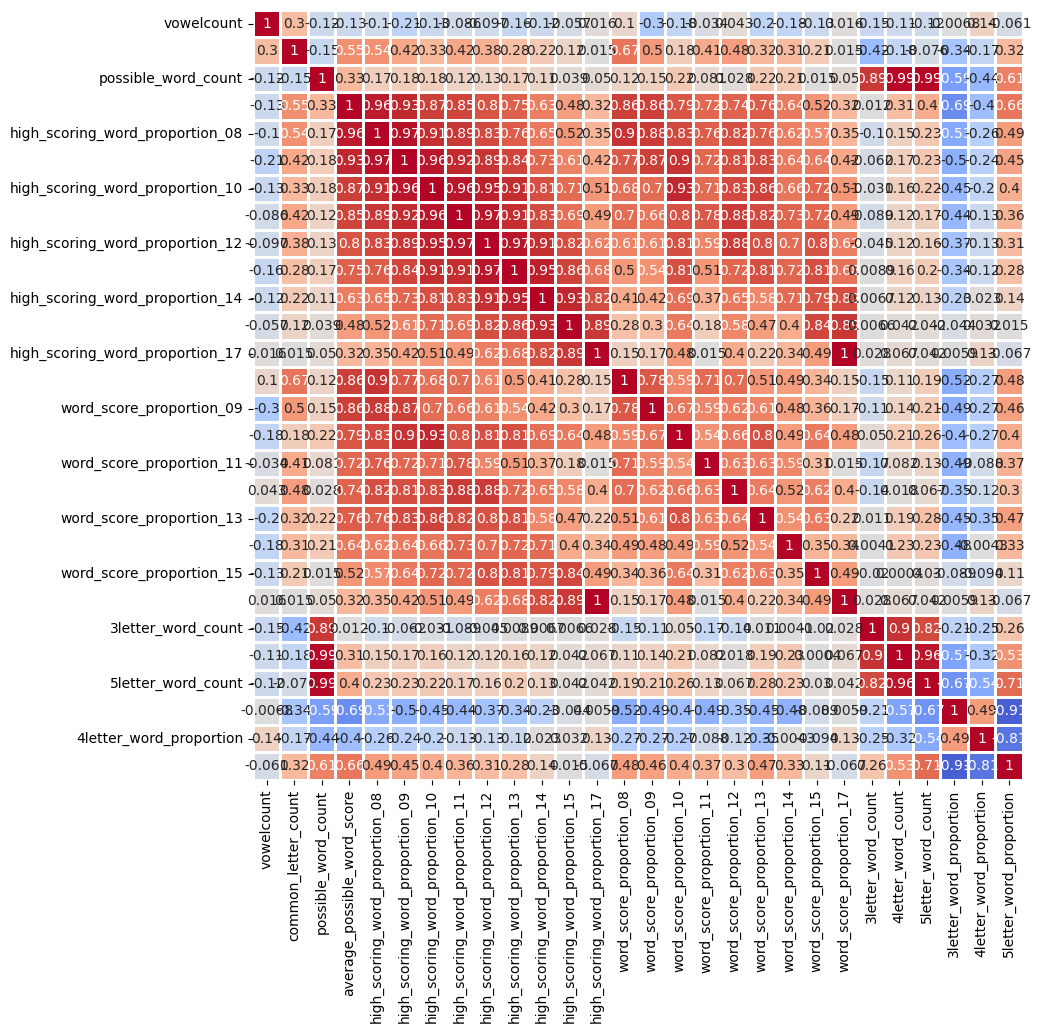

In [17]:
corr_matrix_all = df.corr(numeric_only=True)

# Round the correlation matrix to 2 decimal places
corr_matrix_rounded_all = corr_matrix_all.round(4)

sns.heatmap(corr_matrix_rounded_all, 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            #xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


In [18]:
corr_matrix = df.corrwith(dayScores["scores"])

# Round the correlation matrix to 2 decimal places
corr_matrix_rounded = corr_matrix.round(2)


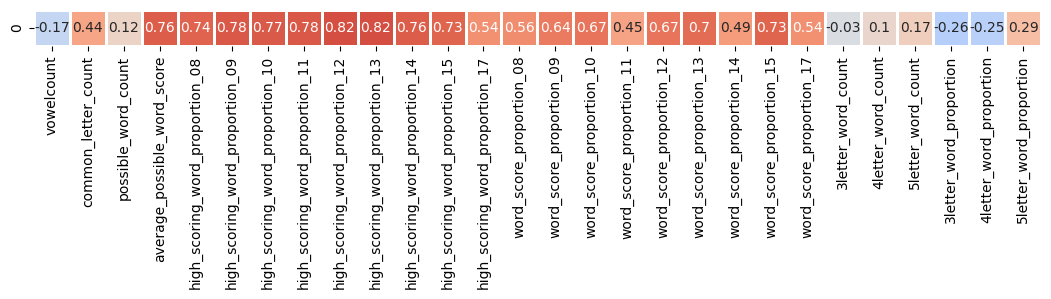

In [19]:
sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


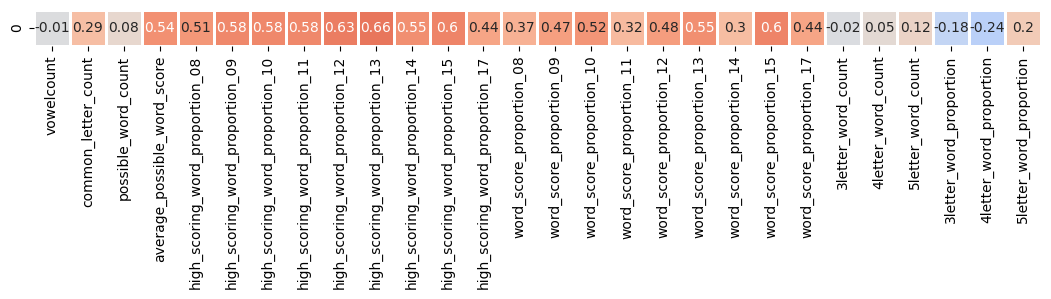

In [20]:
corr_matrix = df.corrwith(dayScores["scores"], method="kendall")
corr_matrix_rounded = corr_matrix.round(2)

sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


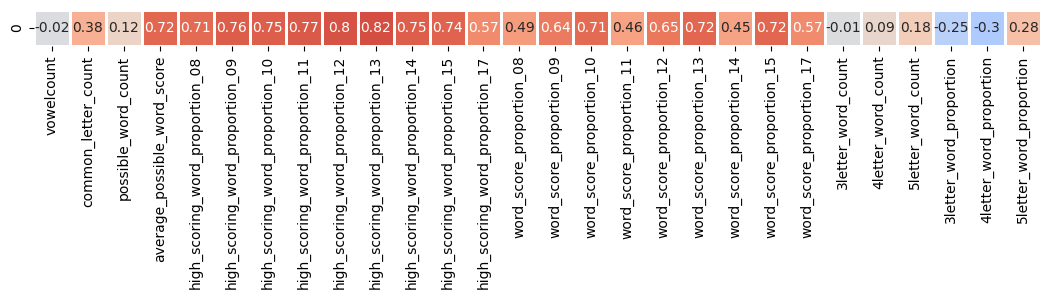

In [21]:
corr_matrix = df.corrwith(dayScores["scores"], method="spearman")
corr_matrix_rounded = corr_matrix.round(2)

sns.heatmap([corr_matrix_rounded], 
            annot=True,      # Display correlation values inside the heatmap cells.
            vmin=-1, vmax=1, # Define the limits of the color scale
            square=True,     # Make sure cells stay square
            xticklabels=list(df.columns),
            cmap="coolwarm", # Set the color map
            linewidths=1,    # Lines between the cells
            cbar=False
            )
fig = plt.gcf()
fig.set_size_inches( 13, 10)
plt.show()


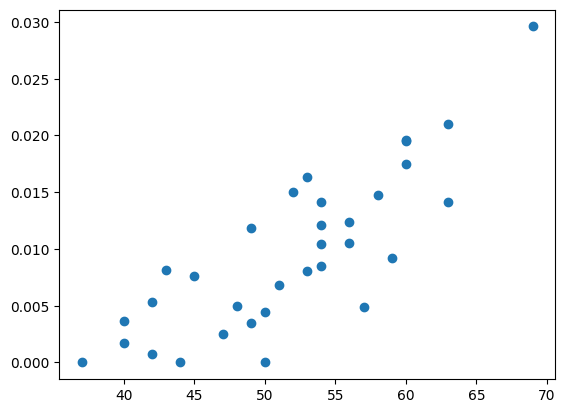

In [22]:
plt.scatter(dayScores["scores"], df['high_scoring_word_proportion_12'])
plt.show()


In [23]:
print(scipy.stats.spearmanr(dayScores["scores"], df['high_scoring_word_proportion_12']))

SignificanceResult(statistic=np.float64(0.8013070162546041), pvalue=np.float64(2.1151017397969352e-08))


In [24]:
new_data_stats = get_new_data_stats("asbeworoahfgpentzkieeoiat")

actual = 54

In [25]:
model_measures = { "name": [], "selectedDatePredictionDiff": [], "overallMeanPredictionDiff": [], "overallStDevPredictionDiff": [], "meanSquaredError": [], "r2Score": []}

[53.63560483]


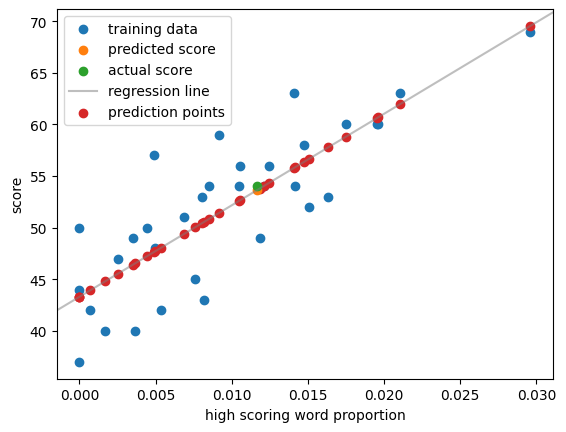

In [26]:
x = dayScores["scores"]
y = df['high_scoring_word_proportion_12'].values.reshape((-1, 1))

model1 = LinearRegression()
model1.fit(y, x)

model1_selected_features = new_data_stats['high_scoring_word_proportion_12']

result1 = model1.predict(np.array(model1_selected_features).reshape(1, -1))
print(result1)

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

plt.scatter(model1_selected_features, result1, label="predicted score", zorder=2)
plt.scatter(model1_selected_features, actual, label="actual score", zorder=2)

plt.plot([model1_selected_features, model1_selected_features], [result1[0],actual], ':r', zorder=1)

plt.axline((0, model1.intercept_), slope=model1.coef_[0], color='C7', alpha=0.5, label='regression line')

predictions = model1.predict(y)
plt.scatter(df['high_scoring_word_proportion_12'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model1 (linear regression)")
model_measures["selectedDatePredictionDiff"].append(abs(result1[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

testing out polynomial regression instead of just linear:

[53.87734568]


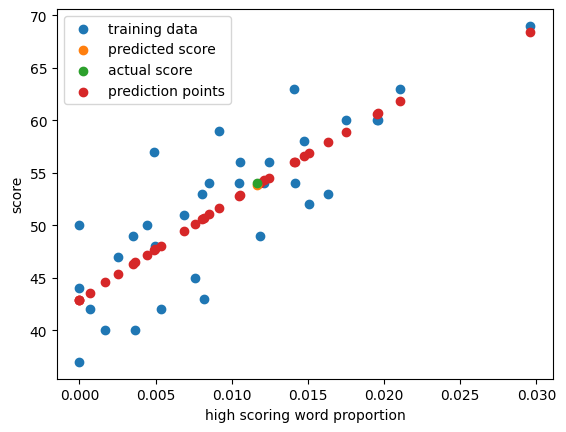

In [27]:
y_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y)

model2 = LinearRegression().fit(y_, x)

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

model2_selected_features = new_data_stats['high_scoring_word_proportion_12']

new_data_stats_transformed = PolynomialFeatures(degree=2, include_bias=False).fit_transform(np.array(model2_selected_features).reshape(1, -1))
result2 = model2.predict(new_data_stats_transformed)
print(result2)

plt.scatter(model2_selected_features, result2, label="predicted score", zorder=2)
plt.scatter(model2_selected_features, actual, label="actual score", zorder=2)

plt.plot([model2_selected_features, model2_selected_features], [result2[0],actual], ':r', zorder=1)

predictions = model2.predict(y_)
plt.scatter(df['high_scoring_word_proportion_12'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model2 (poly regression)")
model_measures["selectedDatePredictionDiff"].append(abs(result2[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

[50.78243288]


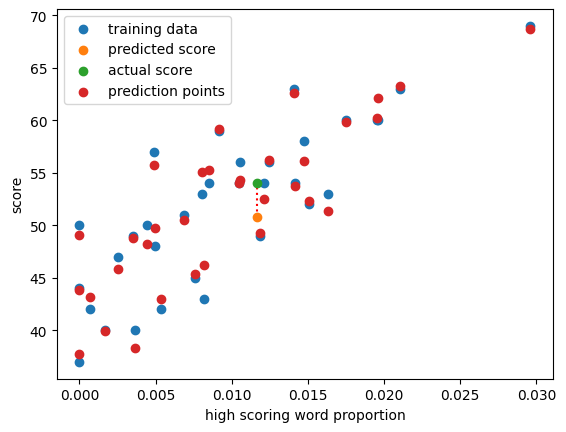

In [28]:
selected_features3 = ['high_scoring_word_proportion_12', 'common_letter_count', 'average_possible_word_score', "word_score_proportion_08","word_score_proportion_09","word_score_proportion_10","word_score_proportion_12","word_score_proportion_13","word_score_proportion_15","word_score_proportion_17"]
y3 = df[selected_features3]

y3_ = PolynomialFeatures( include_bias=False).fit_transform(y3)

model3 = LinearRegression()
model3.fit(y3_, x)


model3_selected_features = new_data_stats[selected_features3]

plt.scatter(df['high_scoring_word_proportion_12'], dayScores["scores"], label="training data",zorder=0)

predict_data_source3_ = PolynomialFeatures( include_bias=False).fit_transform(model3_selected_features)#.reshape(1, -1)
result3 = model3.predict(predict_data_source3_)
print(result3)

plt.scatter(model3_selected_features['high_scoring_word_proportion_12'], result3, label="predicted score", zorder=2)
plt.scatter(model3_selected_features['high_scoring_word_proportion_12'], actual, label="actual score", zorder=2)

plt.plot([model3_selected_features['high_scoring_word_proportion_12'], model3_selected_features['high_scoring_word_proportion_12']], [result3[0],actual], ':r', zorder=1)

predictions = model3.predict(y3_)
plt.scatter(df['high_scoring_word_proportion_12'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("high scoring word proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model3 (poly regression, word score proportion focus)")
model_measures["selectedDatePredictionDiff"].append(abs(result3[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

[51.67067952]


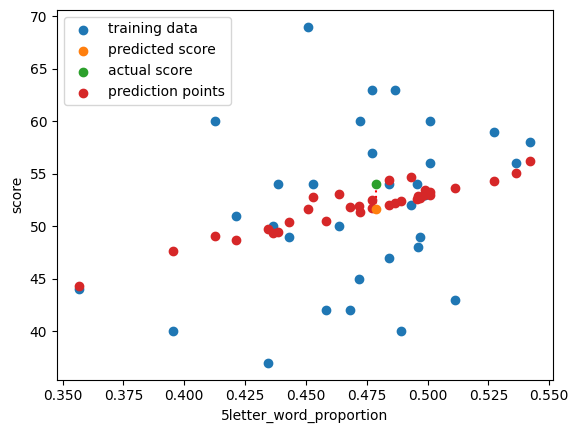

In [29]:
selected_features4 = ['3letter_word_proportion', '4letter_word_proportion', '5letter_word_proportion']
y4 = df[selected_features4]

y4_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y4)

model4 = LinearRegression()
model4.fit(y4_, x)

model4_selected_features = new_data_stats[selected_features4]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

predict_data_source4_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model4_selected_features)#.reshape(1, -1)
result4 = model4.predict(predict_data_source4_)
print(result4)

plt.scatter(model4_selected_features['5letter_word_proportion'], result4, label="predicted score", zorder=2)
plt.scatter(model4_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model4_selected_features['5letter_word_proportion'], model4_selected_features['5letter_word_proportion']], [result4[0],actual], ':r', zorder=1)

predictions = model4.predict(y4_)
plt.scatter(df['5letter_word_proportion'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model4 (poly regression, word length proportion focus)")
model_measures["selectedDatePredictionDiff"].append(abs(result4[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

[53.47997549]


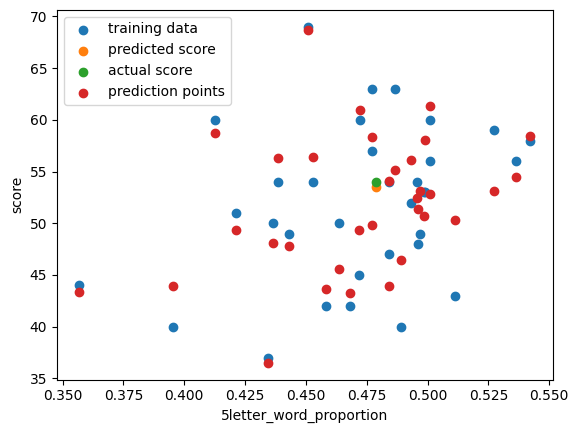

In [30]:
selected_features5 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion']
y5 = df[selected_features5]

y5_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y5)

model5 = LinearRegression()
model5.fit(y5_, x)

model5_selected_features = new_data_stats[selected_features5]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

predict_data_source5_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model5_selected_features)#.reshape(1, -1)
result5 = model5.predict(predict_data_source5_)
print(result5)

plt.scatter(model5_selected_features['5letter_word_proportion'], result5, label="predicted score", zorder=2)
plt.scatter(model5_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model5_selected_features['5letter_word_proportion'], model5_selected_features['5letter_word_proportion']], [result5[0],actual], ':r', zorder=1)

predictions = model5.predict(y5_)
plt.scatter(df['5letter_word_proportion'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model5 (poly regression, high correlation focus)")
model_measures["selectedDatePredictionDiff"].append(abs(result5[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

[54.1605319]


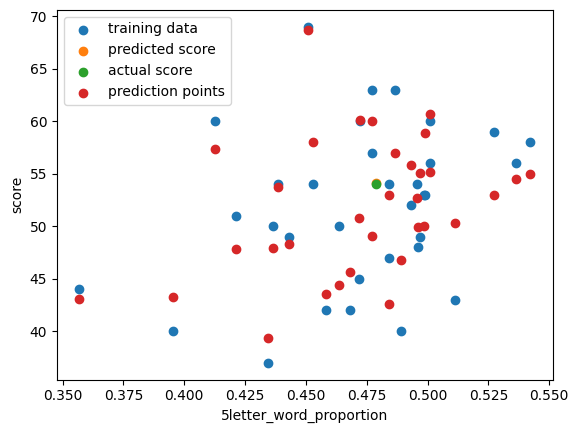

In [31]:
selected_features6 = ['high_scoring_word_proportion_12', 'average_possible_word_score', 'common_letter_count', '5letter_word_proportion']
y6 = df[selected_features6]

#y6_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(y6)

model6 = LinearRegression()
model6.fit(y6, x)

model6_selected_features = new_data_stats[selected_features6]

plt.scatter(df['5letter_word_proportion'], dayScores["scores"], label="training data",zorder=0)

#predict_data_source6_ = PolynomialFeatures(degree=2, include_bias=False).fit_transform(model6_selected_features)#.reshape(1, -1)
result6 = model6.predict(model6_selected_features)
print(result6)

plt.scatter(model6_selected_features['5letter_word_proportion'], result6, label="predicted score", zorder=2)
plt.scatter(model6_selected_features['5letter_word_proportion'], actual, label="actual score", zorder=2)

plt.plot([model6_selected_features['5letter_word_proportion'], model6_selected_features['5letter_word_proportion']], [result6[0],actual], ':r', zorder=1)

predictions = model6.predict(y6)
plt.scatter(df['5letter_word_proportion'], predictions, label="prediction points", zorder=1)

plt.legend()
plt.xlabel("5letter_word_proportion")
plt.ylabel("score")
plt.show()

model_measures["name"].append("model6 (linear regression, high correlation focus)")
model_measures["selectedDatePredictionDiff"].append(abs(result6[0] - actual))

diffs = []
for i in range(len(predictions)):
    diffs.append(abs(predictions[i] - dayScores["scores"][i]))

model_measures["overallMeanPredictionDiff"].append(np.mean(diffs))
model_measures["overallStDevPredictionDiff"].append(np.std(diffs))
model_measures["meanSquaredError"].append(mean_squared_error(dayScores["scores"], predictions))
model_measures["r2Score"].append(r2_score(dayScores["scores"], predictions))

                                                name  \
0                         model1 (linear regression)   
1                           model2 (poly regression)   
2  model3 (poly regression, word score proportion...   
3  model4 (poly regression, word length proportio...   
4   model5 (poly regression, high correlation focus)   
5  model6 (linear regression, high correlation fo...   

   selectedDatePredictionDiff  overallMeanPredictionDiff  \
0                    0.364395                   3.409121   
1                    0.122654                   3.398353   
2                    3.217567                   0.937404   
3                    2.329320                   5.608794   
4                    0.520025                   2.973771   
5                    0.160532                   3.245730   

   overallStDevPredictionDiff  meanSquaredError   r2Score  
0                    2.552712         18.138444  0.677758  
1                    2.550933         18.056063  0.679222  
2     

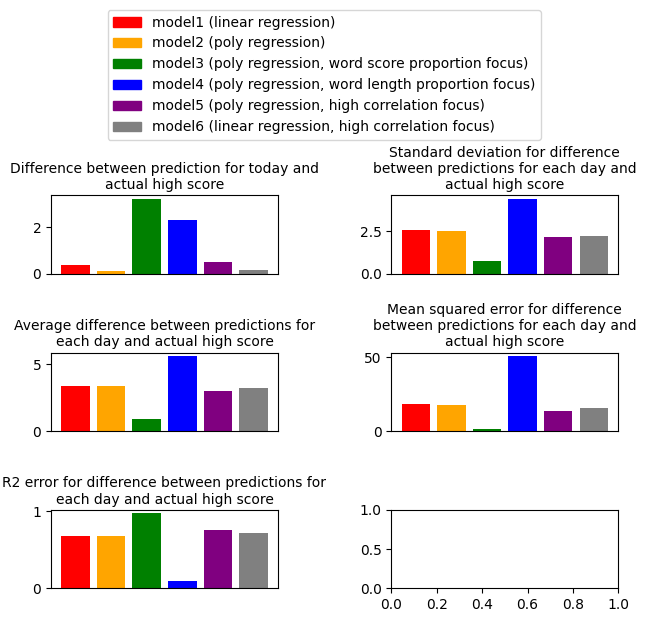

In [32]:
model_prediction_info = pd.DataFrame(model_measures)

print(model_prediction_info)
colors = ["red", "orange", "green", "blue", "purple", "grey"]
#bar_colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:blue', 'tab:purple', 'tab:grey']

fig, axs = plt.subplots(3, 2)

axs[0,0].bar(model_prediction_info["name"], model_prediction_info["selectedDatePredictionDiff"], color=colors)

axs[0,0].set_title("Difference between prediction for today and actual high score", fontsize=10, wrap=True)
#axs[0,0].set_xlabel("Model")
#axs[0,0].set_ylabel("Difference")
axs[0,0].set_xticks([])
#axs[0,0].tick_params('x', labelrotation=90) 

axs[1,0].bar(model_prediction_info["name"], model_prediction_info["overallMeanPredictionDiff"], color=colors)

axs[1,0].set_title("Average difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[1,0].set_xlabel("Model")
#axs[1,0].set_ylabel("Difference")
axs[1,0].set_xticks([])
#axs[1,0].tick_params('x', labelrotation=90) 

axs[0,1].bar(model_prediction_info["name"], model_prediction_info["overallStDevPredictionDiff"], color=colors)

axs[0,1].set_title("Standard deviation for difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[0,1].set_xlabel("Model")
#axs[0,1].set_ylabel("Difference")
axs[0,1].set_xticks([])
#axs[0,1].tick_params('x', labelrotation=90) 

axs[1,1].bar(model_prediction_info["name"], model_prediction_info["meanSquaredError"], color=colors)

axs[1,1].set_title("Mean squared error for difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[1,1].set_xlabel("Model")
#axs[1,1].set_ylabel("Difference")
axs[1,1].set_xticks([])
#axs[1,1].tick_params('x', labelrotation=90) 

axs[2,0].bar(model_prediction_info["name"], model_prediction_info["r2Score"], color=colors)

axs[2,0].set_title("R2 error for difference between predictions for each day and actual high score", fontsize=10, wrap=True)
#axs[2,0].set_xlabel("Model")
#axs[2,0].set_ylabel("Difference")
axs[2,0].set_xticks([])
#axs[2,0].tick_params('x', labelrotation=90) 

#axs[0,0].legend()

#handles, labels = axs[0,0].get_legend_handles_labels()
#fig.legend(handles, labels, loc='upper center')
#axs[0,0].get_legend().remove()
#fig.legend(handles=colors, labels=model_measures["name"])

patches = []

for i in range(len(colors)):
    patches.append(mpatches.Patch(color=colors[i], label=model_measures["name"][i]))

fig.legend(bbox_to_anchor=(0.5, 1.3), handles=patches, loc='upper center')
fig.tight_layout()
fig.subplots_adjust(wspace=0.5,hspace=1)